# 01 — Data Pipeline: EuroSAT Loading, Spatial Block Split & UC Merced Holdout

This notebook covers Module 1: Data Pipeline. We will:
1. Load the EuroSAT base dataset.
2. Implement a **Spatially Blocked Split** strategy to prevent spatial data leakage, and compare it to a naive random split.
3. Plot class distributions across train, val, and test splits for both partitioning methods.
4. Load and inspect the UC Merced holdout dataset mapped to EuroSAT classes, verifying cross-dataset pipeline compatibility.

### Spatial Data Leakage & Split Strategy
In satellite image classification, adjacent tiles are highly correlated. If individual tiles are split randomly (Naive Split), adjacent or overlapping tiles end up in both training and test sets. This causes **spatial leakage**, leading to overconfident validation metrics that do not generalize to new locations.

To resolve this, we group sequential tiles of each class into blocks of $B = 40$. Since EuroSAT's folder listing order corresponds to geographic extraction sequences, grouping sequential indices into blocks clusters geographically adjacent images. We then partition these entire blocks (70/15/15 ratio) rather than individual images, ensuring complete spatial separation between splits.

In [1]:
import sys, os
# Resolve project root dynamically
if os.path.exists('src'):
    ROOT_DIR = '.'
else:
    ROOT_DIR = '..'
sys.path.append(ROOT_DIR)

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from src.dataset import load_eurasat, naive_random_split, block_split, EUROSAT_CLASSES, UCMercedMappedDataset
from src.utils import set_seed

SEED = 42
set_seed(SEED)

DATA_ROOT = os.path.join(ROOT_DIR, "data", "raw")
PROCESSED_DIR = os.path.join(ROOT_DIR, "data", "processed")
os.makedirs(PROCESSED_DIR, exist_ok=True)

## 1. Load EuroSAT Base Dataset

In [2]:
# Load EuroSAT base dataset (download=False assumes it is already present in data/raw)
eurosat = load_eurasat(root=DATA_ROOT, download=False)
labels = np.array([sample[1] for sample in eurosat.samples])

print(f"EuroSAT dataset loaded. Total samples: {len(eurosat)}")
print(f"Number of classes: {len(EUROSAT_CLASSES)}")
print("Classes:", EUROSAT_CLASSES)

EuroSAT dataset loaded. Total samples: 27000
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2. Generate Split Manifests (Naive vs Block Splits)
Here we execute both partitioners using a 70/15/15 split ratio.

In [3]:
naive_splits = naive_random_split(len(labels), splits=(0.7, 0.15, 0.15), seed=SEED)
block_splits = block_split(labels, splits=(0.7, 0.15, 0.15), block_size=40, seed=SEED)

for name, s in [("Naive random split", naive_splits), ("Block split", block_splits)]:
    print(f"\n{name}:")
    print(f"  Train size: {len(s['train'])}")
    print(f"  Val size:   {len(s['val'])}")
    print(f"  Test size:  {len(s['test'])}")


Naive random split:
  Train size: 18900
  Val size:   4050
  Test size:  4050

Block split:
  Train size: 18800
  Val size:   3960
  Test size:  4240


## 3. Visualize Class Distribution In Each Split
We plot and compare the class balance across splits for both naive and block partitioning strategies to confirm they maintain consistent distributions.

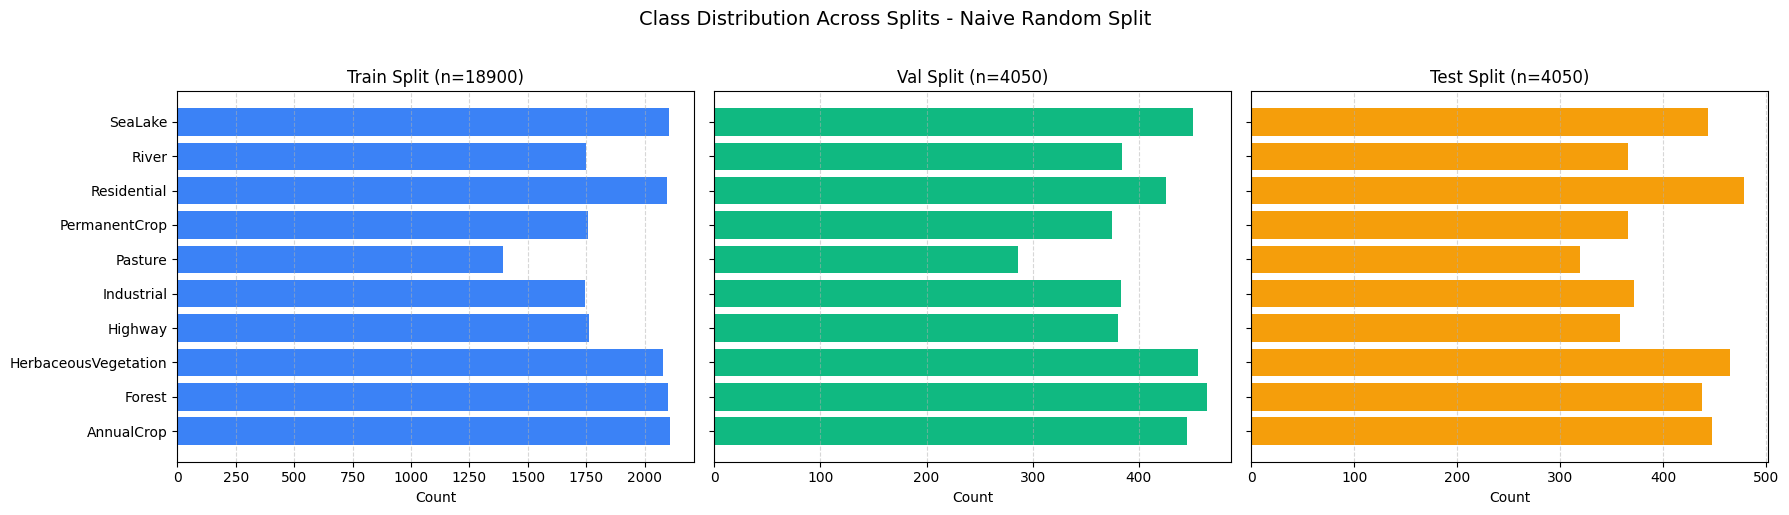

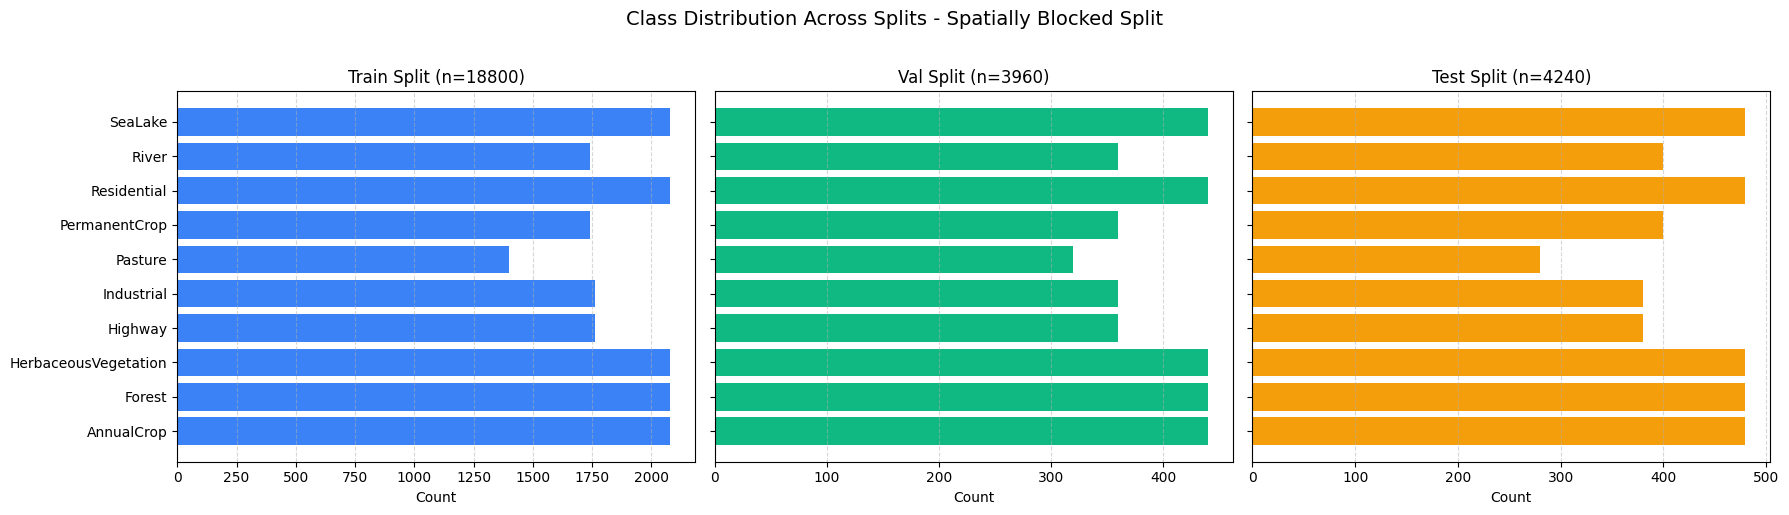

In [4]:
def plot_split_distributions(split_dict, labels, class_names, split_name_title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    splits = ['train', 'val', 'test']
    colors = ['#3b82f6', '#10b981', '#f59e0b']
    
    for idx, split in enumerate(splits):
        split_labels = labels[split_dict[split]]
        counts = np.bincount(split_labels, minlength=len(class_names))
        
        axes[idx].barh(class_names, counts, color=colors[idx])
        axes[idx].set_title(f"{split.capitalize()} Split (n={len(split_labels)})")
        axes[idx].set_xlabel("Count")
        axes[idx].grid(axis='x', linestyle='--', alpha=0.5)
        
    fig.suptitle(f"Class Distribution Across Splits - {split_name_title}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_split_distributions(naive_splits, labels, EUROSAT_CLASSES, "Naive Random Split")
plot_split_distributions(block_splits, labels, EUROSAT_CLASSES, "Spatially Blocked Split")

## 4. Persist Split Manifest
Save the generated split index mappings to disk so they can be loaded consistently across training scripts and evaluation notebooks.

In [5]:
np.savez(
    os.path.join(PROCESSED_DIR, "split_manifest.npz"),
    naive_train=naive_splits["train"], naive_val=naive_splits["val"], naive_test=naive_splits["test"],
    block_train=block_splits["train"], block_val=block_splits["val"], block_test=block_splits["test"],
    seed=SEED,
)
print("Saved split_manifest.npz successfully to", PROCESSED_DIR)

Saved split_manifest.npz successfully to ..\data\processed


## 5. Load and Evaluate UC Merced Holdout Dataset
Verify that our pipeline can load the out-of-domain UC Merced dataset (with classes mapped to EuroSAT) and explore its class distribution.

Loaded UC Merced holdout dataset. Size: 1100 samples


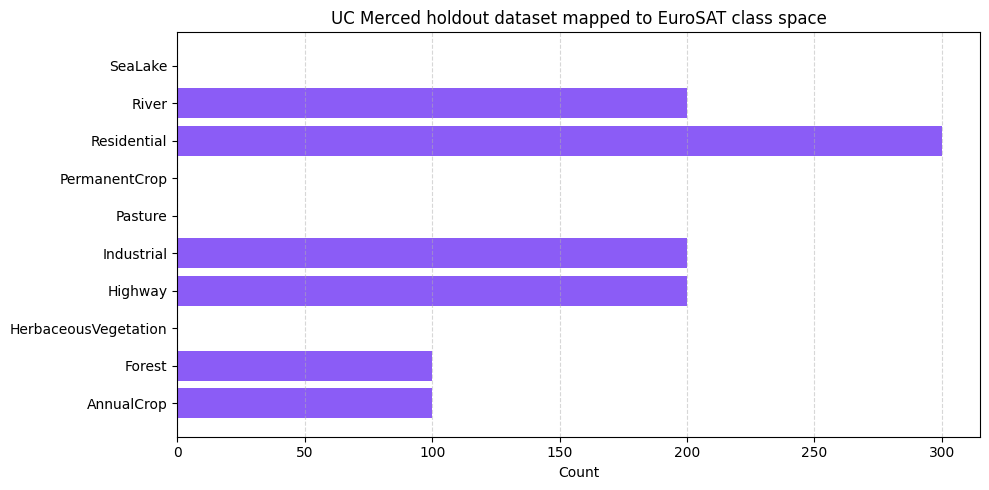

In [6]:
ucm_root = os.path.join(DATA_ROOT, "uc_merced")
if os.path.exists(ucm_root):
    # Load UC Merced mapped dataset
    ucm_dataset = UCMercedMappedDataset(root_dir=ucm_root, transform=None)
    print(f"Loaded UC Merced holdout dataset. Size: {len(ucm_dataset)} samples")
    
    # Extract mapped labels
    ucm_labels = [sample[1] for sample in ucm_dataset.samples]
    counts = np.bincount(ucm_labels, minlength=10)
    
    # Plot UC Merced mapped class distribution
    plt.figure(figsize=(10, 5))
    plt.barh(EUROSAT_CLASSES, counts, color='#8b5cf6')
    plt.title("UC Merced holdout dataset mapped to EuroSAT class space")
    plt.xlabel("Count")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    print(f"UC Merced directory not found at: {ucm_root}. Please run download_uc_merced.py first.")